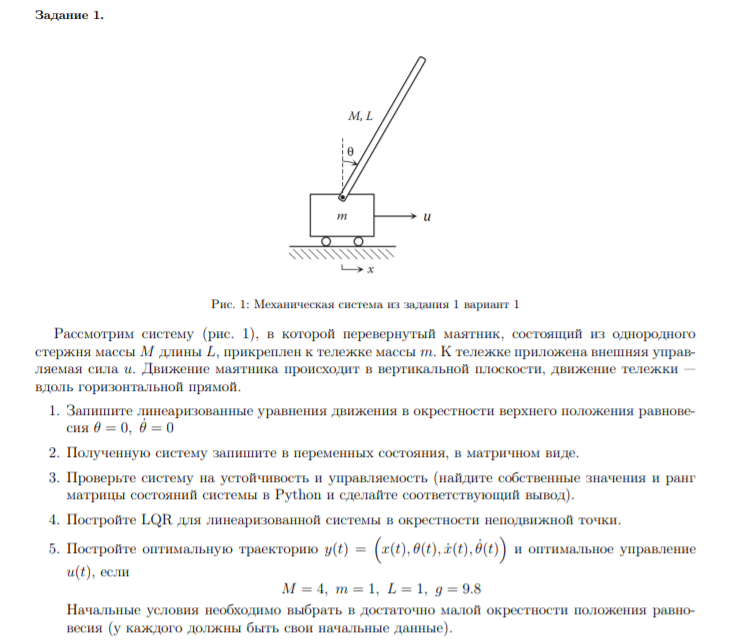

In [1]:
import matplotlib.pyplot as plt
import control 
import numpy as np
from scipy import integrate

In [2]:
M=4
m=1
L=1
g=9.8
d=(4/6)*M*L + (7/6)*m*L
c11=-g*M*L/(2*d)
c12=7*L/(6*d)
c21=(m+M)*g/d
c22=-1/d
#u=np.sin(5*t)
#x(0)=0
#Θ(0)=Pi/15
#Θ(T)=0
#x(T)=0

A = np.array([[0, 0, 1, 0],[0, 0, 0, 1],[0, c11, 0, 0],[0, c21, 0, 0]])
B = np.array([[0], [0],[c12], [c22]])

P=control.ctrb(A, B) # матрица управляемости
P

array([[ 0.        ,  0.30434783,  0.        ,  1.33383743],
       [ 0.        , -0.26086957,  0.        , -3.33459357],
       [ 0.30434783,  0.        ,  1.33383743,  0.        ],
       [-0.26086957,  0.        , -3.33459357,  0.        ]])

In [3]:
# проверка критерия управляемости
np.linalg.matrix_rank(P) # вычисление ранга

4

In [4]:
# проверка критерия устойчивости
np.linalg.eigvals(A) # вычисление собственных значений

array([ 0.        ,  0.        ,  3.57527743, -3.57527743])

    Система управляема и неустойчива

In [5]:
# LQR

Q = np.eye(4)
R = 1
K = control.lqr(A, B, Q, R)[0]

S = control.lqr(A, B, Q, R)
S
#print(Q)
#K

(array([[  -1.        , -118.27806454,   -3.89080718,  -34.54286085]]),
 array([[   3.89080718,   34.54286085,    7.06919026,   12.08072197],
        [  34.54286085, 1972.72570202,  122.31888909,  596.104618  ],
        [   7.06919026,  122.31888909,   23.9800745 ,   42.89151445],
        [  12.08072197,  596.104618  ,   42.89151445,  182.45440013]]),
 array([-3.7160637 +0.j        , -3.4458177 +0.j        ,
        -0.33257043+0.29841092j, -0.33257043-0.29841092j], dtype=complex64))

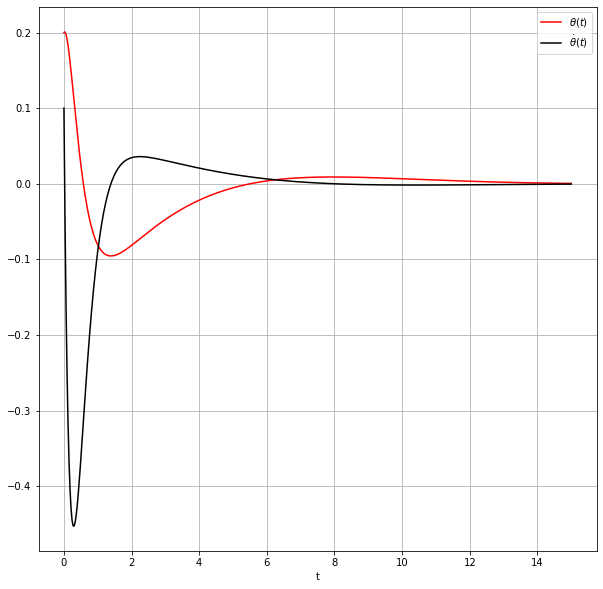

In [17]:
T = 15

def f(t, x):
    u = -np.dot(K, x)
    dxdt = np.dot(A, x) + np.dot(B, u)
    return dxdt



sol = integrate.solve_ivp(f, (0, T), (-1, 0.2, 1, 0.1), t_eval = np.linspace(0, T, 500))
x = sol.y
t = sol.t

u = -np.dot(K,x)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(t,x[1], 'r', label = r'$\theta(t)$')
ax.plot(t,x[3], 'k', label = r'$\dot\theta(t)$')
ax.set_xlabel("t")
ax.legend()
ax.grid()

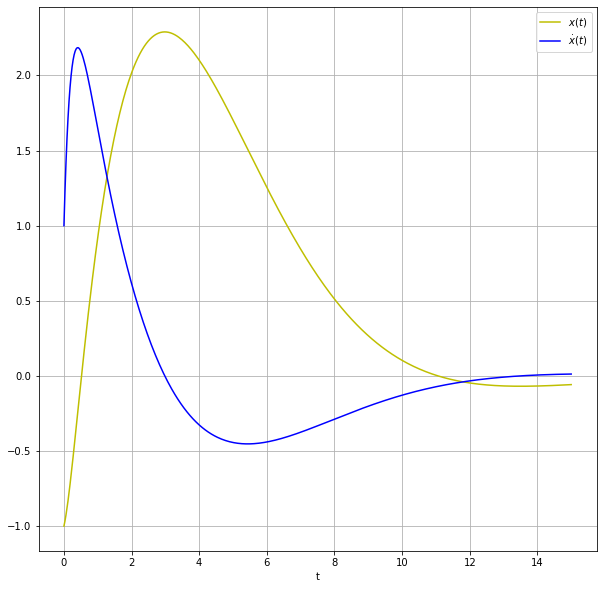

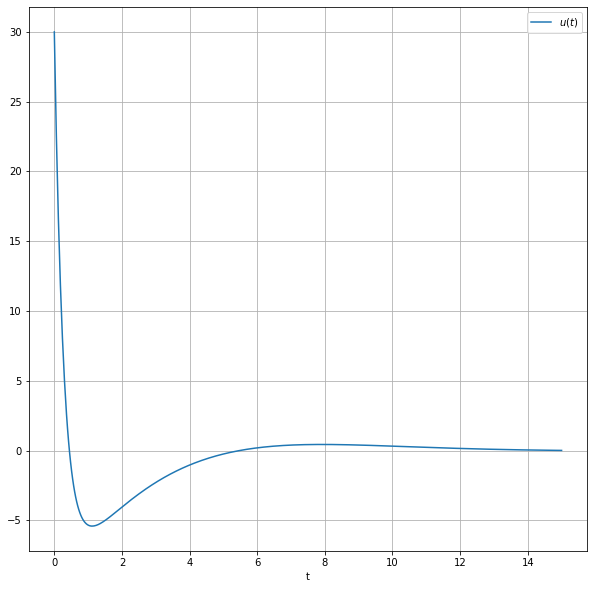

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(t,x[0], 'y', label = r'$x(t)$')
ax.plot(t,x[2], 'b', label = r'$\dot x(t)$')
ax.set_xlabel("t")
ax.legend()
ax.grid()

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(t,u[0], label = r'$u(t)$')
ax.set_xlabel("t")
ax.legend()
ax.grid()